<a href="https://colab.research.google.com/github/joaopeazevedo/modulo1/blob/main/Profissao_Cientista_de_Dados_M13_Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from google.colab import files

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

In [13]:
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO - MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv")

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


In [6]:
df.describe()

,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto
count,1107.000000,1107.000000,1107.000000,1107.000000
mean,2070.997290,522.269196,372.257453,68.109304
std,2961.257627,1339.559852,1239.475017,241.158310
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,1269.000000,0.000000,0.000000,0.000000
75%,2849.000000,0.000000,0.000000,0.000000
max,19788.000000,14550.000000,18899.000000,4349.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           1107 non-null   object
 1   Marca           1107 non-null   object
 2   Preco_Normal    1107 non-null   int64 
 3   Preco_Desconto  1107 non-null   int64 
 4   Preco_Anterior  1107 non-null   int64 
 5   Desconto        1107 non-null   int64 
 6   Categoria       1107 non-null   object
dtypes: int64(4), object(3)
memory usage: 60.7+ KB


In [8]:
df['Categoria'].value_counts()

,count
Categoria,
lacteos,447
belleza-y-cuidado-personal,239
congelados,235
verduras,64
instantaneos-y-sopas,57
comidas-preparadas,46
frutas,19


# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [15]:
df.groupby('Categoria')['Preco_Normal'].mean()

,Preco_Normal
Categoria,
belleza-y-cuidado-personal,1783.556485
comidas-preparadas,3095.043478
congelados,2108.042553
frutas,1724.473684
instantaneos-y-sopas,765.491228
lacteos,2385.219239
verduras,1343.296875


In [10]:
df.groupby('Categoria')['Preco_Normal'].median()


,Preco_Normal
Categoria,
belleza-y-cuidado-personal,1569.0
comidas-preparadas,3290.0
congelados,1519.0
frutas,1195.0
instantaneos-y-sopas,439.0
lacteos,989.0
verduras,1180.0


Digite aqui as categorias:

Todas as categorias tem algum grau de diferença entre média e mediana.
As categorias: ... tem a média acima da mediana indicando que a maioria dos produtos é mais barata e tem alguns produtos mais caros puxando a média pra cima. E as categorias: ... tem a média abaixo da mediana, indicando que em geral os produtos são mais caros, com alguns de valor mais baixo puxando a média para baixo.

As categorias com maior distância entre média e mediana são
- congelados
- frutas
- instantaneos-y-sopas
- lacteos

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [19]:
#Seu código aqui
df.groupby('Categoria')['Preco_Normal'].std()

resumo = pd.DataFrame({
      'media' : df.groupby('Categoria')['Preco_Normal'].mean(),
      'mediana' : df.groupby('Categoria')['Preco_Normal'].median(),
      'desvio_padrao' : df.groupby('Categoria')['Preco_Normal'].std()
      })
resumo

,media,mediana,desvio_padrao
Categoria,,,
belleza-y-cuidado-personal,1783.556485,1569.0,2210.041719
comidas-preparadas,3095.043478,3290.0,2019.911428
congelados,2108.042553,1519.0,2111.539896
frutas,1724.473684,1195.0,1639.151114
instantaneos-y-sopas,765.491228,439.0,1170.232869
lacteos,2385.219239,989.0,3925.816164
verduras,1343.296875,1180.0,1012.699625


Digite nesse campo o comportamento que você identificou.

A categoria com maior desvio padrão (lacteos) tem também a maior distância entre a média e a mediana.

Essa tendência está presente também em congelados. E indica que temos valores desporporcionais no conjunto.

Porém nos casos de belleza-y-cuidado-personal e comidas-preparadas temos uma diferença relativamente baixa entre a média e a mediana, mas com alto desvio padrão. Isso indica que temos uma grande elasticidade de valores nos cojuntos, mas com distribuição proporcional acima e abaixo da média.


# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

<Axes: >

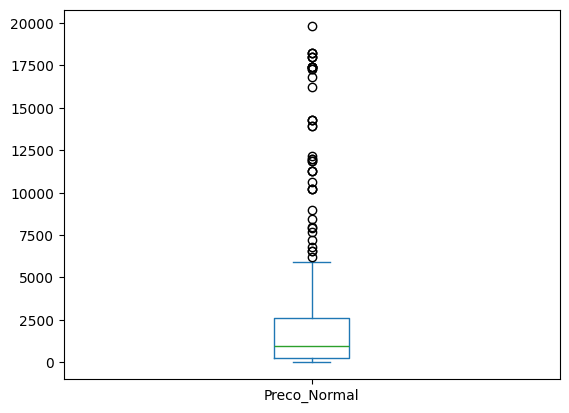

In [24]:
#Seu código aqui
lacteos = df.loc[df['Categoria'] == 'lacteos']

lacteos['Preco_Normal'].plot(kind='box')


No boxplot podemos consolidar o que visualizamos anteriormente, a caixa central fica espremida perto da base, com a mediana mais próxima do primeiro quartil, indicando uma base grande de itens com preço mais baixo e com outliers com valores muito distantes.

Essa visualização faz sentido se considerarmos a prateleira dos lacteos que pode conter de um leite simples até queijos muito caros, justificando essa elasticidade de preço.

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

<Axes: xlabel='Categoria'>

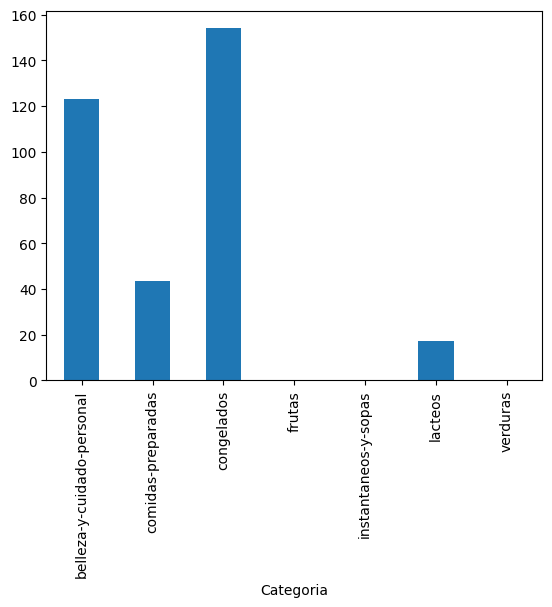

In [25]:
# Seu código aqui
desconto = df.groupby('Categoria')['Desconto'].mean()

desconto.plot(kind='bar')


As categorias de belleza e congelados apresentam maiores índices de desconto. E frutas, instantaeos e verduras são categorias que não tiveram nenhum tipo de desconto.

A análise inicial que podemos fazer é de que na categoria de congelados, temos alguma necessidade de escoamento, podendo ser, provavelmente, o vencimento de alguns itens.

Quando observamos a categoria de belleza, nas visões anteriores ela era mais equilibrada entre média e mediana, indicando preços balanceados.  


# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [36]:
# Seu código aqui
df.groupby(['Categoria','Marca'])['Desconto'].mean()

px.treemap(df, path=['Categoria', 'Marca'], values='Desconto')
fig = px.treemap(df, path=['Categoria', 'Marca'], values='Desconto')
fig.show()
